# Stage 09 — Feature Engineering

In [6]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy pandas matplotlib

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# project dataset: one row per hobby-box tier, + packs_per_box from box_products
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ct = pd.read_csv(_root / "data" / "raw" / "card_tiers.csv")
bp = pd.read_csv(_root / "data" / "raw" / "box_products.csv")
df = ct.merge(
    bp[["product_id", "product_line", "packs_per_box", "retail_price_usd"]],
    on="product_id", how="left",
)
df.head()

,product_id,box_format,tier_name,tier_group,print_run,is_numbered,is_autograph,is_ssp,odds_pack,odds_box,est_value_usd,value_basis,source_note,product_line,packs_per_box,retail_price_usd
0,2025-26-topps-chrome-bkb-hobby,Hobby,Base,base,NaN,False,False,False,NaN,NaN,0.5,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,20,379.99
1,2025-26-topps-chrome-bkb-hobby,Hobby,Base Refractor,parallel,NaN,False,False,False,3.0,0.15,3.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,20,379.99
2,2025-26-topps-chrome-bkb-hobby,Hobby,Prism Refractor,parallel,NaN,False,False,False,5.0,0.25,3.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,20,379.99
3,2025-26-topps-chrome-bkb-hobby,Hobby,Wave Refractor,parallel,NaN,False,False,False,14.0,0.70,3.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,20,379.99
4,2025-26-topps-chrome-bkb-hobby,Hobby,Negative Refractor,parallel,NaN,False,False,False,31.0,1.55,8.0,rough_estimate_v0,NaN,2025-26 Topps Chrome Basketball,20,379.99


## Engineered features

Three features, each with implementation, rationale (naming the Stage 08 EDA insight it
comes from), and a correlation / plot check at the end. Feature 3 encodes a categorical
column. Helper versions live in `src/features.py`.

In [8]:
# Feature 1 of 3 — a ratio (the EV weight for a tier).
df['expected_hits_per_box'] = df['packs_per_box'] / df['odds_pack']
df[['tier_name', 'odds_pack', 'packs_per_box', 'expected_hits_per_box']].head()

,tier_name,odds_pack,packs_per_box,expected_hits_per_box
0,Base,NaN,20,NaN
1,Base Refractor,3.0,20,6.666667
2,Prism Refractor,5.0,20,4.000000
3,Wave Refractor,14.0,20,1.428571
4,Negative Refractor,31.0,20,0.645161


### Rationale for Feature 1

1. `expected_hits_per_box = packs_per_box / odds_pack` — the expected number of cards of
   this tier in one box.
2. This is exactly the weight the EV formula multiplies by card value (`docs/ev.md`): a
   Refractor at 1:3 packs contributes ~7 cards/box, a SuperFractor at 1:30,000 ~0.0007.
3. Raw `odds_pack` alone doesn't tell a model how much of this you actually get — this
   does. NaN for the ~13 SSP/auto tiers where Topps publishes only card-level odds (hw08
   missingness); left as NaN, not filled with 0.

In [9]:
# Feature 2 of 3 — a transform.
df['log_odds_pack'] = np.log10(df['odds_pack'])
df[['odds_pack', 'log_odds_pack']].describe().T

,count,mean,std,min,25%,50%,75%,max
odds_pack,181.0,3519.198895,13156.920371,1.0,76.000000,286.000000,1209.000000,138789.000000
log_odds_pack,181.0,2.479064,0.988136,0.0,1.880814,2.456366,3.082426,5.142355


### Rationale for Feature 2

`log_odds_pack = log10(odds_pack)`. Raw `odds_pack` runs 1:3 to 1:2,000,000; hw07 showed a
linear model on that raw scale fails (R² 0.20) because scarcity is multiplicative — each
rarity step is ~2–3× rarer, not a fixed amount rarer. `log10` turns those steps into
roughly equal distances, the scale a value / EV model should regress on. Same NaN rows as
Feature 1.

In [10]:
# Feature 3 of 3 — encode the categorical column `tier_group`.
#   one-hot     pd.get_dummies(df, columns=['tier_group'])
#   label       LabelEncoder().fit_transform(df['tier_group'])
#   frequency   df['tier_group'].map(df['tier_group'].value_counts(normalize=True))
# One-hot chosen — see rationale below.
df = pd.get_dummies(df, columns=['tier_group'], prefix='tg')
for c in df.filter(like='tg_').columns:
    df[c] = df[c].astype(int)
df.filter(like='tg_').head()

,tg_auto,tg_base,tg_insert,tg_parallel,tg_variation
0,0,1,0,0,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0


### Rationale for Feature 3

`tier_group` (base / parallel / insert / auto / variation) is **nominal** — no natural
order — with only 5 levels, so I one-hot encode it into `tg_*` 0/1 columns.

1. **Why not label / frequency.** Label encoding assigns 0–4 and implies
   `auto (3) > insert (2)` — an ordering the model would try to exploit, false structure.
   Frequency encoding maps each group to its row share (parallel ≈ 0.56, auto ≈ 0.24,
   insert ≈ 0.14); groups with similar counts collapse onto nearly the same number and
   become indistinguishable. hw08's value-by-group boxplot showed the split that matters —
   autos and 1/1 variations sit well above parallels and inserts *at the same rarity*.
2. **What one-hot buys the model.** Value depends on rarity **and** type: an autograph at
   1:100 is worth more than a parallel at 1:100. Separate `tg_*` columns let a linear
   model give each type its own offset on top of `log_odds_pack`.
3. **Edge cases.** `tier_group` has no missing values, so this produces no NaN (unlike
   Features 1–2). `tg_variation` is 1 for only 3 of 194 rows (hw08 flagged the imbalance) —
   near-constant, so the model barely moves on it, but that is honest; the other encodings
   would bury those rows inside a shared value. `base` can serve as the reference level if
   the model drops one dummy to avoid collinearity with the intercept.

tg_base                 -0.524
expected_hits_per_box   -0.502
tg_insert               -0.108
tg_variation            -0.023
tg_parallel              0.035
tg_auto                  0.297
log_odds_pack            0.881
Name: log_value, dtype: float64
expected_hits_per_box NaN rows: 13


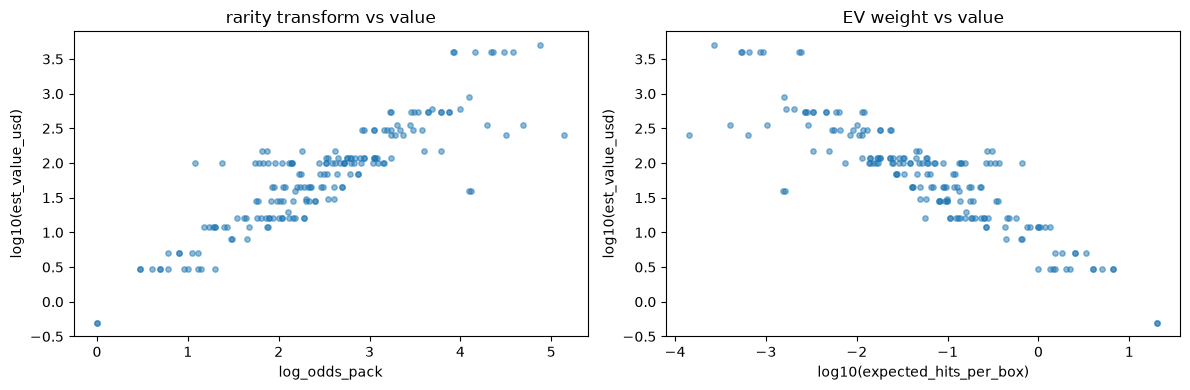

In [11]:
# Feature <-> target correlation + visual check. Target: log10(est_value_usd).
feat_cols = ["expected_hits_per_box", "log_odds_pack"] + list(df.filter(like="tg_").columns)
chk = df[feat_cols].assign(log_value=np.log10(df["est_value_usd"]))
corr = chk.corr(numeric_only=True)["log_value"].drop("log_value").sort_values()
print(corr.round(3))
print("expected_hits_per_box NaN rows:", int(df["expected_hits_per_box"].isna().sum()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(df["log_odds_pack"], np.log10(df["est_value_usd"]), s=15, alpha=.5)
ax[0].set(xlabel="log_odds_pack", ylabel="log10(est_value_usd)", title="rarity transform vs value")
ax[1].scatter(np.log10(df["expected_hits_per_box"]), np.log10(df["est_value_usd"]), s=15, alpha=.5)
ax[1].set(xlabel="log10(expected_hits_per_box)", ylabel="log10(est_value_usd)", title="EV weight vs value")
plt.tight_layout(); plt.show()

### What the check tells us

- `log_odds_pack` correlates **+0.88** with `log10(est_value_usd)` — the transform
  captures almost all of the rarity -> value signal, and the left scatter is roughly
  linear (raw `odds_pack` is not).
- `expected_hits_per_box` is **-0.50**: more expected hits per box = a commoner tier =
  lower value. The right scatter shows the same slope.
- Among the dummies, `tg_auto` is **+0.30** and `tg_base` **-0.52**, with `tg_parallel`
  / `tg_insert` near zero — tier *type* shifts value on top of rarity, which is exactly
  why one-hot beats collapsing the groups.